# Exploration


## Library imported

In [234]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
dataset = pd.read_csv('Tayko.csv')
with pd.option_context('display.max_rows', 6): display(dataset)
dataset.columns

,sequence_number,US,source_a,source_c,source_b,source_d,source_e,source_m,source_o,source_h,...,last_update_days_ago,1st_update_days_ago,Web order,Gender=male,Address_is_res,Purchase,Spending,Partition,Unnamed: 26,Unnamed: 27
0,1,1,0,0,1,0,0,0,0,0,...,3662,3662,1,0,1,1,128,s,NaN,NaN
1,2,1,0,0,0,0,1,0,0,0,...,2900,2900,1,1,0,0,0,s,NaN,NaN
2,3,1,0,0,0,0,0,0,0,0,...,3883,3914,0,0,0,1,127,t,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997,1998,1,0,0,0,0,0,0,0,0,...,3394,3394,0,0,0,0,0,t,NaN,NaN
1998,1999,1,0,0,0,0,0,0,0,0,...,253,253,0,1,1,0,0,t,NaN,NaN
1999,2000,1,0,0,0,0,0,0,0,0,...,1261,1844,0,0,0,0,0,t,NaN,NaN


Index(['sequence_number', 'US', 'source_a', 'source_c', 'source_b', 'source_d',
       'source_e', 'source_m', 'source_o', 'source_h', 'source_r', 'source_s',
       'source_t', 'source_u', 'source_p', 'source_x', 'source_w', 'Freq',
       'last_update_days_ago', '1st_update_days_ago', 'Web order',
       'Gender=male', 'Address_is_res', 'Purchase', 'Spending', 'Partition',
       'Unnamed: 26', 'Unnamed: 27'],
      dtype='object')

In [235]:
print(len(dataset))

2000


### For Spending vs Freq

In [236]:
# Training Set
x = dataset[['Spending']]
x1 = dataset['Spending']
y = dataset['Freq']
x.head

<bound method NDFrame.head of       Spending
0          128
1            0
2          127
3            0
4            0
...        ...
1995        30
1996        10
1997         0
1998         0
1999         0

[2000 rows x 1 columns]>

In [237]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

print(x_train)

      Spending
0          128
816          0
790          0
361         50
592          0
...        ...
1791       288
1096         0
1932         0
235        130
1061       551

[1600 rows x 1 columns]


In [238]:
print(x_test)

      Spending
674          0
1699       184
1282         0
1315      1289
1210         0
...        ...
400        163
763          0
385        149
1667       463
1820       138

[400 rows x 1 columns]


In [239]:
print(y_train)

0       2
816     2
790     0
361     3
592     1
       ..
1791    2
1096    1
1932    0
235     1
1061    1
Name: Freq, Length: 1600, dtype: int64


In [240]:
print(y_test)

674     2
1699    2
1282    1
1315    9
1210    0
       ..
400     2
763     0
385     1
1667    2
1820    2
Name: Freq, Length: 400, dtype: int64


### For Spending vs Last_update

In [241]:
# Training Set
x_spe_up = dataset[['Spending']]
x1_spe_up = dataset['Spending']
y_spe_up = dataset['last_update_days_ago']
x_spe_up.head

<bound method NDFrame.head of       Spending
0          128
1            0
2          127
3            0
4            0
...        ...
1995        30
1996        10
1997         0
1998         0
1999         0

[2000 rows x 1 columns]>

In [242]:
from sklearn.model_selection import train_test_split
x_train_spe_up, x_test_spe_up, y_train_spe_up, y_test_spe_up = train_test_split(x_spe_up, y_spe_up, test_size = 0.2, random_state = 1)

print(x_train_spe_up)

      Spending
0          128
816          0
790          0
361         50
592          0
...        ...
1791       288
1096         0
1932         0
235        130
1061       551

[1600 rows x 1 columns]


In [243]:
print(x_test_spe_up)

      Spending
674          0
1699       184
1282         0
1315      1289
1210         0
...        ...
400        163
763          0
385        149
1667       463
1820       138

[400 rows x 1 columns]


In [244]:
print(y_train_spe_up)

0       3662
816      841
790      744
361      841
592     2809
        ... 
1791    2366
1096    1010
1932    3619
235     1946
1061     912
Name: last_update_days_ago, Length: 1600, dtype: int64


In [245]:
print(y_test_spe_up)

674     1346
1699     434
1282    3717
1315    1128
1210    2765
        ... 
400      864
763     3311
385      314
1667    1563
1820    1962
Name: last_update_days_ago, Length: 400, dtype: int64


## Forming train and test

In [246]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)


LinearRegression()

In [247]:
# For Spending vs Last_update
from sklearn.linear_model import LinearRegression
regressor2 = LinearRegression()
regressor2.fit(x_train_spe_up, y_train_spe_up)

LinearRegression()

## Predicting test set

In [248]:
y_pred = regressor.predict(x_test)

In [249]:
y_pred_spe_up = regressor2.predict(x_test)

### scatters plots SPENDING vs. FREQ (Visualising the Training set results)

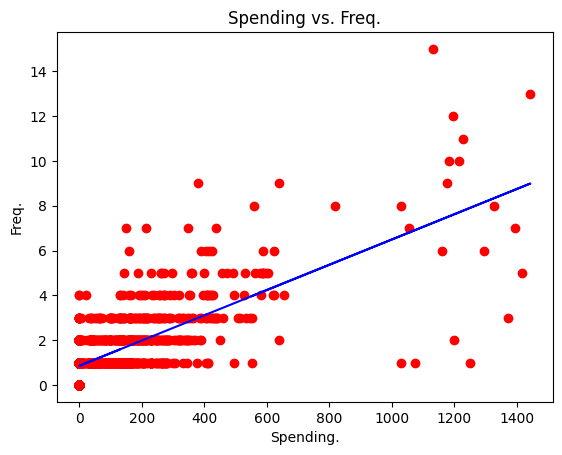

In [250]:
plt.scatter(x_train, y_train, color = 'red')
plt.plot(x_train, regressor.predict(x_train), color = 'blue')
plt.title('Spending vs. Freq.')
plt.xlabel('Spending.')
plt.ylabel('Freq.')
plt.show()

### scatters plots SPENDING vs. FREQ (Visualising the Test set results)

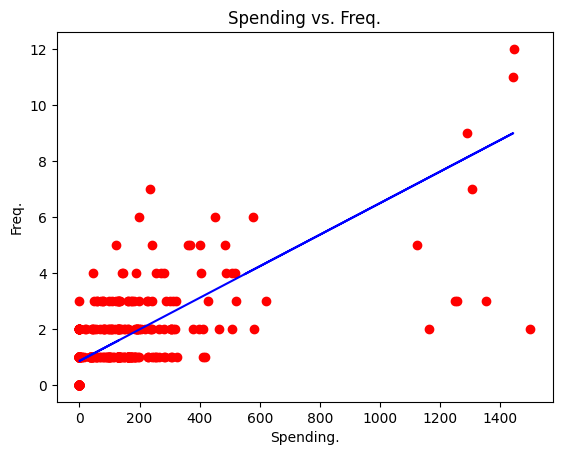

In [251]:
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, regressor.predict(x_train), color = 'blue')
plt.title('Spending vs. Freq.')
plt.xlabel('Spending.')
plt.ylabel('Freq.')
plt.show()

### scatters plots SPENDING vs. LAST_UPDATE (Visualising the Training set results)

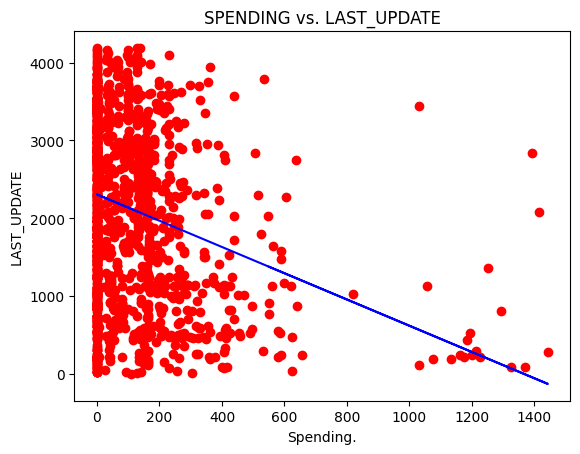

In [252]:
plt.scatter(x_train_spe_up, y_train_spe_up, color = 'red')
plt.plot(x_train, regressor2.predict(x_train_spe_up), color = 'blue')
plt.title('SPENDING vs. LAST_UPDATE')
plt.xlabel('Spending.')
plt.ylabel('LAST_UPDATE')
plt.show()

### scatters plots SPENDING vs. LAST_UPDATE (Visualising the Test set results)

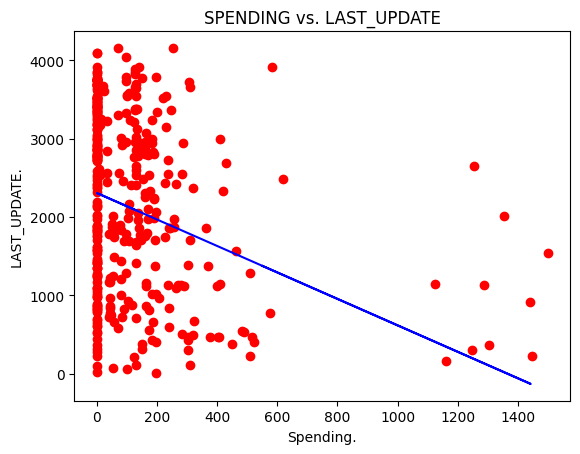

In [253]:
plt.scatter(x_test_spe_up, y_test_spe_up, color = 'red')
plt.plot(x_train, regressor2.predict(x_train_spe_up), color = 'blue')
plt.title('SPENDING vs. LAST_UPDATE')
plt.xlabel('Spending.')
plt.ylabel('LAST_UPDATE.')
plt.show()

# Fitting first model

## Heatmap for B1

<ipython-input-254-39b58a9a3617>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = dataset.corr()


                      sequence_number        US  source_a  source_c  source_b  \
sequence_number              1.000000 -0.036730 -0.022295 -0.021229  0.031930   
US                          -0.036730  1.000000  0.104397  0.083786 -0.032876   
source_a                    -0.022295  0.104397  1.000000 -0.092688 -0.096145   
source_c                    -0.021229  0.083786 -0.092688  1.000000 -0.061535   
source_b                     0.031930 -0.032876 -0.096145 -0.061535  1.000000   
source_d                     0.032352  0.096000 -0.079185 -0.050680 -0.052570   
source_e                     0.006557 -0.088102 -0.160490 -0.102717 -0.106548   
source_m                     0.031255  0.049440 -0.049291 -0.031547 -0.032724   
source_o                    -0.002881  0.005541 -0.070849 -0.045345 -0.047036   
source_h                     0.017553  0.008413 -0.089579 -0.057332 -0.059471   
source_r                     0.011710  0.036651 -0.103197 -0.066048 -0.068512   
source_s                    

<Axes: >

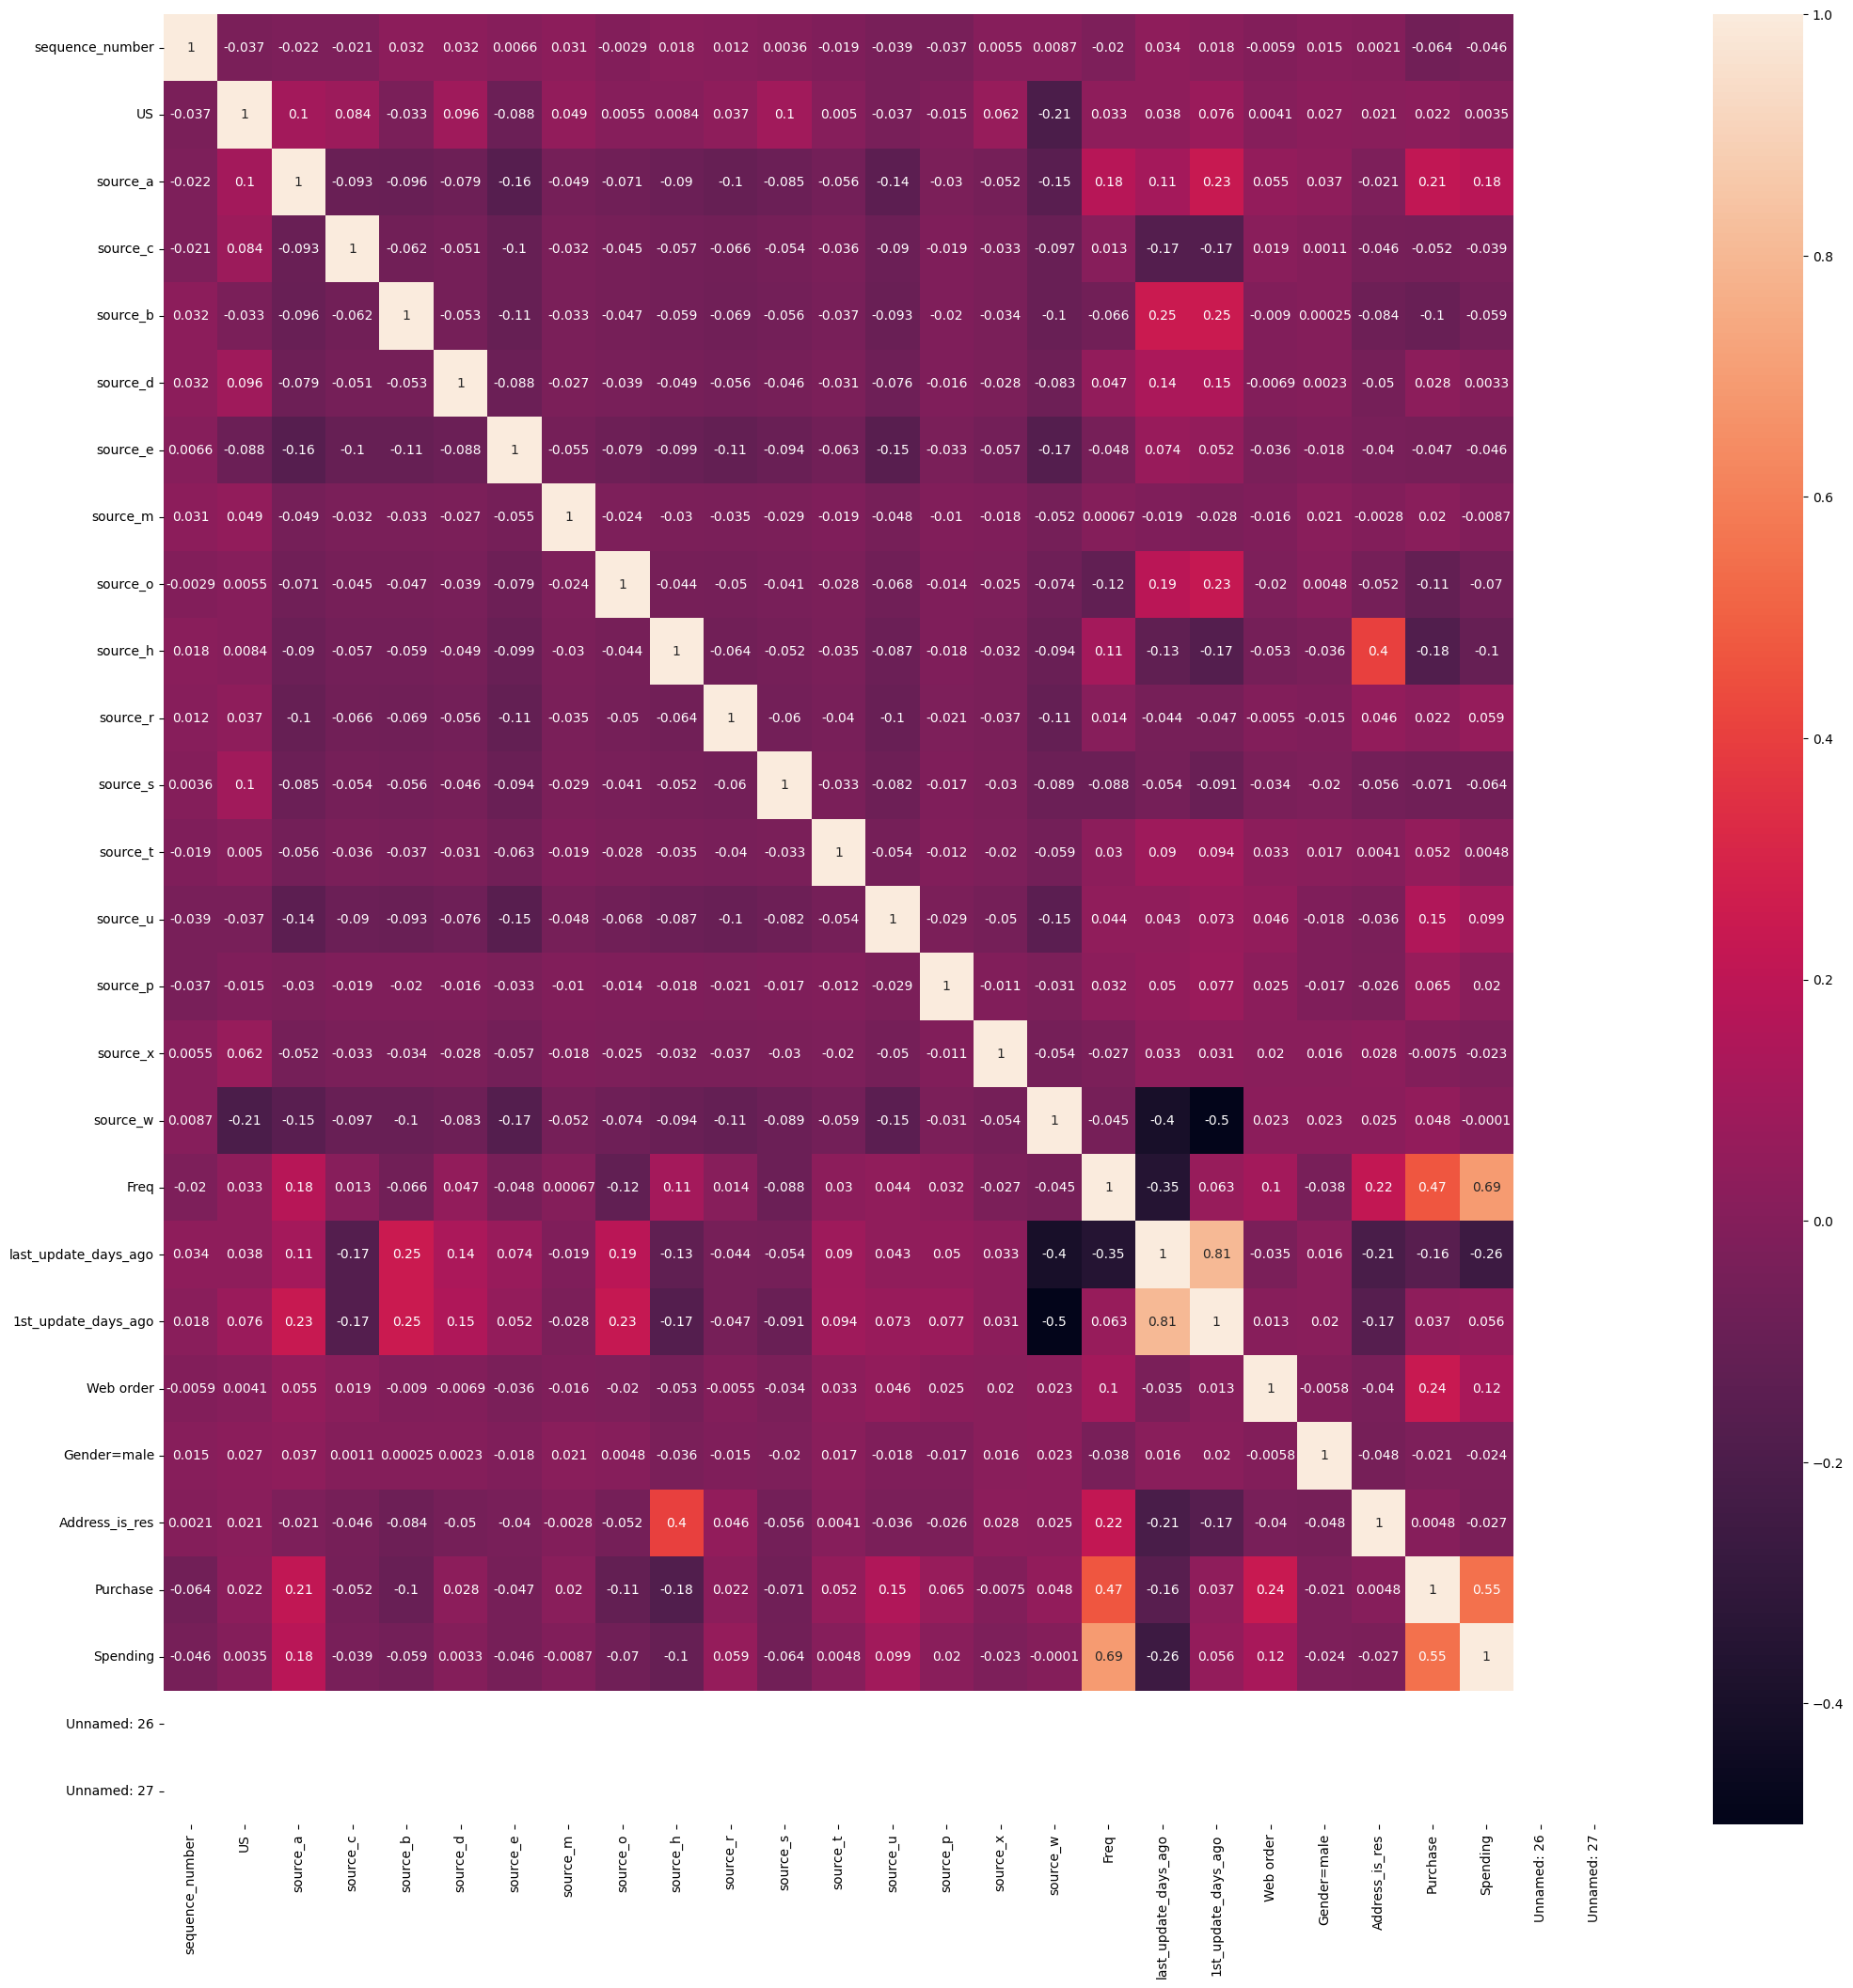

In [254]:
corr_matrix = dataset.corr()
print(corr_matrix)
fig, ax = plt.subplots(figsize=(25,25))
sn.heatmap(corr_matrix, annot=True)

## Seperate dataset x_train x

In [255]:
training_dataset = dataset.copy()
validation_dataset = dataset.copy()
training_dataset = training_dataset[dataset['Partition'] == 't'].drop(columns=['Partition'])
validation_dataset = validation_dataset[dataset['Partition'] == 'v'].drop(columns=['Partition'])

In [256]:
training_dataset

,sequence_number,US,source_a,source_c,source_b,source_d,source_e,source_m,source_o,source_h,...,Freq,last_update_days_ago,1st_update_days_ago,Web order,Gender=male,Address_is_res,Purchase,Spending,Unnamed: 26,Unnamed: 27
2,3,1,0,0,0,0,0,0,0,0,...,2,3883,3914,0,0,0,1,127,NaN,NaN
4,5,1,0,1,0,0,0,0,0,0,...,1,869,869,0,0,0,0,0,NaN,NaN
7,8,1,0,0,1,0,0,0,0,0,...,1,3397,3397,0,1,0,0,0,NaN,NaN
8,9,1,1,0,0,0,0,0,0,0,...,4,525,2914,1,1,0,1,489,NaN,NaN
12,13,1,0,0,0,0,0,0,0,0,...,1,2802,2802,1,1,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,1995,1,0,0,0,0,1,0,0,0,...,2,1136,1400,0,1,0,1,184,NaN,NaN
1996,1997,1,0,0,0,0,0,0,0,0,...,1,2633,2633,1,1,0,1,10,NaN,NaN
1997,1998,1,0,0,0,0,0,0,0,0,...,0,3394,3394,0,0,0,0,0,NaN,NaN
1998,1999,1,0,0,0,0,0,0,0,0,...,1,253,253,0,1,1,0,0,NaN,NaN


In [257]:
validation_dataset

,sequence_number,US,source_a,source_c,source_b,source_d,source_e,source_m,source_o,source_h,...,Freq,last_update_days_ago,1st_update_days_ago,Web order,Gender=male,Address_is_res,Purchase,Spending,Unnamed: 26,Unnamed: 27
9,10,1,1,0,0,0,0,0,0,0,...,1,3215,3215,0,0,0,1,174,NaN,NaN
13,14,1,1,0,0,0,0,0,0,0,...,5,2081,2438,0,1,0,1,1416,NaN,NaN
15,16,0,0,0,0,0,0,0,0,0,...,1,2523,2523,1,0,0,0,0,NaN,NaN
28,29,1,0,0,0,0,0,0,0,0,...,1,3299,3299,0,0,0,1,90,NaN,NaN
30,31,1,0,0,0,0,0,0,0,0,...,0,3090,3090,0,0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,1986,1,0,0,0,0,0,0,0,0,...,1,659,659,1,1,0,1,188,NaN,NaN
1986,1987,1,0,0,0,0,1,0,0,0,...,4,1710,2982,0,0,1,1,145,NaN,NaN
1988,1989,1,0,0,0,0,0,0,0,0,...,1,3299,3299,1,1,0,1,69,NaN,NaN
1993,1994,1,0,0,0,0,0,0,1,0,...,0,3746,3746,1,0,0,0,0,NaN,NaN


In [258]:
print(len(dataset))

2000


## **Feature Scaling on Training Set & Test Set** Fitting First Model

In [259]:
# Training Set
x_train_f = training_dataset[['Freq','last_update_days_ago','Web order','Gender=male','US','Address_is_res']]
y_train_f = training_dataset['Spending']

# Testing Set
x_test_f = validation_dataset[['Freq','last_update_days_ago','Web order','Gender=male','US','Address_is_res']]
y_test_f = validation_dataset['Spending']

# Index(['sequence_number', 'US', 'source_a', 'source_c', 'source_b', 'source_d',
#        'source_e', 'source_m', 'source_o', 'source_h', 'source_r', 'source_s',
#        'source_t', 'source_u', 'source_p', 'source_x', 'source_w', 'Freq',
#        'last_update_days_ago', '1st_update_days_ago', 'Web order',
#        'Gender=male', 'Address_is_res', 'Purchase', 'Spending', 'Partition',
#        'Unnamed: 26', 'Unnamed: 27'],

In [260]:
print(x_train_f)

      Freq  last_update_days_ago  Web order  Gender=male  US  Address_is_res
2        2                  3883          0            0   1               0
4        1                   869          0            0   1               0
7        1                  3397          0            1   1               0
8        4                   525          1            1   1               0
12       1                  2802          1            1   1               0
...    ...                   ...        ...          ...  ..             ...
1994     2                  1136          0            1   1               0
1996     1                  2633          1            1   1               0
1997     0                  3394          0            0   1               0
1998     1                   253          0            1   1               1
1999     1                  1261          0            0   1               0

[800 rows x 6 columns]


In [261]:
print(y_train_f)

2       127
4         0
7         0
8       489
12        0
       ... 
1994    184
1996     10
1997      0
1998      0
1999      0
Name: Spending, Length: 800, dtype: int64


In [262]:
print(x_test_f)

      Freq  last_update_days_ago  Web order  Gender=male  US  Address_is_res
9        1                  3215          0            0   1               0
13       5                  2081          0            1   1               0
15       1                  2523          1            0   0               0
28       1                  3299          0            0   1               0
30       0                  3090          0            0   1               0
...    ...                   ...        ...          ...  ..             ...
1985     1                   659          1            1   1               0
1986     4                  1710          0            0   1               1
1988     1                  3299          1            1   1               0
1993     0                  3746          1            0   1               0
1995     1                  1701          1            0   1               0

[700 rows x 6 columns]


In [263]:
print(y_test_f)

9        174
13      1416
15         0
28        90
30         0
        ... 
1985     188
1986     145
1988      69
1993       0
1995      30
Name: Spending, Length: 700, dtype: int64


In [264]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

scaler = StandardScaler().fit(x_train_f)
x_train_scaled1 = scaler.transform(x_train_f)
x_test_scaled1 = scaler.transform(x_test_f)

In [265]:
model1 = LinearRegression()
model1.fit(x_train_scaled1,y_train_f)
print(model1.coef_)
print(model1.intercept_)
print("")
print("Features :", x_train_f.columns.tolist())
print("Coefficient :", model1.coef_)
print("Intercept :", model1.intercept_)

[ 1.42144535e+02 -1.15212496e+01  4.82317979e+00 -3.72055392e-02
  6.40044609e+00 -4.12416679e+01]
98.43750000000001

Features : ['Freq', 'last_update_days_ago', 'Web order', 'Gender=male', 'US', 'Address_is_res']
Coefficient : [ 1.42144535e+02 -1.15212496e+01  4.82317979e+00 -3.72055392e-02
  6.40044609e+00 -4.12416679e+01]
Intercept : 98.43750000000001


Features : ['Freq', 'last_update_days_ago', 'Web order', 'Gender=male', 'US', 'Address_is_res']                          
Coefficient : [ 1.42144535e+02 -1.15212496e+01  4.82317979e+00 -3.72055392e-02
  6.40044609e+00 -4.12416679e+01]                         
Intercept : 98.43750000000001                     


From Estimate Multiple Regression Equation
y = b0 + b1x1 + b2x2 + b3x3 + ...
Given B0 is Intercept, B1 and go on is coefficients, and X1 and go on is a Variable or in this called features.

Answer is 98.438 + (142.144 * Freq) + (-11.521 * last_update_days_ago) + (4.823 * Web order) + (-0.037 * Gender=male) + (6.400 * US) + (-41.241 * Address_is_res) **ANSWER**

****If we need to reduce the number of predictors, which
predictor(s) would be dropped from the model?****       
- Drop last_update_days_ago, web order, gender, and US address because P-Value is very low.

## **RMSE evaluation (Root Mean Squared Error)**

In [266]:
y1_pred = model1.predict(x_test_scaled1)
rmse = mean_squared_error(y_test_f,y1_pred, squared=False)
print("RMSE = ", rmse)

RMSE =  135.3559875379643


# Fitting Second Model

## **Feature Scaling on Training Set & Test Set** Fitting Second Model

In [267]:
# Training Set
x_train_fit_s = training_dataset[['Freq','Purchase']]
y_train_fit_s = training_dataset['Spending']

# Testing Set
x_test_fit_s = validation_dataset[['Freq','Purchase']]
y_test_fit_s = validation_dataset['Spending']

# Index(['sequence_number', 'US', 'source_a', 'source_c', 'source_b', 'source_d',
#        'source_e', 'source_m', 'source_o', 'source_h', 'source_r', 'source_s',
#        'source_t', 'source_u', 'source_p', 'source_x', 'source_w', 'Freq',
#        'last_update_days_ago', '1st_update_days_ago', 'Web order',
#        'Gender=male', 'Address_is_res', 'Purchase', 'Spending', 'Partition',
#        'Unnamed: 26', 'Unnamed: 27'],

In [268]:
print(x_train_fit_s)

      Freq  Purchase
2        2         1
4        1         0
7        1         0
8        4         1
12       1         0
...    ...       ...
1994     2         1
1996     1         1
1997     0         0
1998     1         0
1999     1         0

[800 rows x 2 columns]


In [269]:
print(y_train_fit_s)

2       127
4         0
7         0
8       489
12        0
       ... 
1994    184
1996     10
1997      0
1998      0
1999      0
Name: Spending, Length: 800, dtype: int64


In [270]:
print(x_test_fit_s)

      Freq  Purchase
9        1         1
13       5         1
15       1         0
28       1         1
30       0         0
...    ...       ...
1985     1         1
1986     4         1
1988     1         1
1993     0         0
1995     1         1

[700 rows x 2 columns]


In [271]:
print(y_test_fit_s)

9        174
13      1416
15         0
28        90
30         0
        ... 
1985     188
1986     145
1988      69
1993       0
1995      30
Name: Spending, Length: 700, dtype: int64


In [272]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

scaler2 = StandardScaler().fit(x_train_fit_s)
x_train_scaled2 = scaler2.transform(x_train_fit_s)
x_test_scaled2 = scaler2.transform(x_test_fit_s)

In [273]:
model2 = LinearRegression()
model2.fit(x_train_scaled2,y_train_fit_s)
print(model2.coef_)
print(model2.intercept_)
print("")
print("Features :", x_train_fit_s.columns.tolist())
print("Coefficient :", model2.coef_)
print("Intercept :", model2.intercept_)

[113.94691747  49.76936185]
98.43750000000001

Features : ['Freq', 'Purchase']
Coefficient : [113.94691747  49.76936185]
Intercept : 98.43750000000001


Features : ['Freq', 'Purchase']                      
Coefficient : [113.94691747  49.76936185]                         
Intercept : 98.43750000000001                    

From Estimate Multiple Regression Equation y = b0 + b1x1 + b2x2 + b3x3 + ... Given B0 is Intercept, B1 and go on is coefficients, and X1 and go on is a Variable or in this called features.

Answer is 98.438 + (113.947 * Freq) + (49.769 * Purchase) **ANSWER**

## **RMSE evaluation (Root Mean Squared Error)**

In [274]:
y2_pred = model2.predict(x_test_scaled2)
rmse = mean_squared_error(y_test_fit_s,y2_pred, squared=False)
print("RMSE = ", rmse)

RMSE =  129.4064333040359


## **MAPE (Mean Absolute Percentage Error)** --> ข้อมูลมี0 = พัง!

In [275]:
from sklearn.metrics import mean_absolute_percentage_error
y2_pred = model2.predict(x_test_scaled2)
mape = mean_absolute_percentage_error(y_test_fit_s, y2_pred)
print(mape)

9.619232592411608e+16
